# Week 5 Day 3: LangGraph — Stateful, Multi-Step & Cyclical Agent Workflows
Continuing from day 2. Yesterday i used LangChain's `AgentExecutor` which is basically one ReAct loop, decide -> call tool -> observe -> repeat until it thinks its done. Today im moving to LangGraph, which makes me draw out the workflow as an actual graph of nodes and edges instead of hiding it inside one executor loop. This should give me control over branching, looping back, and pausing for a human, which i noted at the end of day 2 was something i couldn't really see or control in `AgentExecutor`.

## Goal
- understand StateGraph, nodes, edges, conditional edges and the shared State object
- design a State schema for a concrete workflow and sketch the graph before writing code
- build a linear graph first, then add a self-correction loop with conditional edges
- add a human-in-the-loop interrupt before a "risky" step
- add persistence (checkpointer) + time travel for debugging, and compare AgentExecutor vs LangGraph


In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: C:\Users\imama\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


## Task 1: Graph Concepts & State Design

### Building blocks
- **State**: one shared dict/object (TypedDict or pydantic model) that gets passed between every node. Every node reads from it and returns a partial update, LangGraph merges that update into the state automatically. This replaces the "scratchpad" and "chat_history" that was in Langchain
- **Node**: just a python function (state) -> dict. Each node does one job (retrieve, generate, critique etc) and returns only the keys it changed.
- **Edge**: Its an arrow from one node to the next, `graph.add_edge("a", "b")`. Always goes the same way
- **Conditional edge**: instead of a fixed next node, you give it a routing function `(state) -> str` that returns the name of whichever node should run next. This is what makes loops and branches possible, e.g. "if quality score is too low, go back to generate, otherwise go to finish".
- **StateGraph**: the object that ties all of this together: you register the State schema, add nodes, add edges (including conditional ones), pick an entry point, and .compile() so its runnable

This is basically the same idea as day 1's while loop, except now the loop's shape is explicit instead of implicit in a while condition, and I can add extra branches without rewriting the loop itself

### My workflow: a laptop recommendation advisor
Reusing the `products.json` laptop catalog from day 2, the agent takes a customer request (e.g. "budget laptop with long battery life"), searches the catalog, drafts a recommendation, critiques its own draft, loops back to regenerate if the critique isn't good enough, then pauses for human approval before "finalizing" the recommendation (risky step, since in a real product this could trigger an email or a purchase order).

### State schema


In [1]:
from typing import TypedDict, Optional, List

In [10]:
class AdvisorState(TypedDict):
    query: str                     #original customer req
    plan: str                      #what the plan node will search for
    retrieved: List[dict]          #products pulled from the catalogue
    draft: str                     #current draft recc
    critique: str                  #feedback from the critique node
    quality_score: int             #1-10, set by the critique node
    retries: int                   #how many times we've looped back to generate
    max_retries: int               #safety cap
    approved: Optional[bool]       #human decision, None until the interrupt is resumed
    log: List[str]                 # running trace of what happened, for debugging
    final_recommendation: Optional[str]

### Graph sketch

```
                 ┌──────────┐
                 │  START   │
                 └────┬─────┘
                      ▼
                 ┌──────────┐
                 │   plan   │   turn the customer query into search criteria
                 └────┬─────┘
                      ▼
                 ┌──────────┐
                 │ retrieve │   look up matching laptops in products.json
                 └────┬─────┘
                      ▼
                 ┌──────────┐
          ┌────▶ │ generate │   draft a recommendation from retrieved products
          │      └────┬─────┘
          │           ▼
          │      ┌──────────┐
          │      │ critique │   score the draft, decide pass/fail
          │      └────┬─────┘
          │           │  conditional edge
          │  score < 7 and retries < max_retries
          └───────────┘
                      │  else (score >= 7, or retries exhausted)
                      ▼
              ┌────────────────┐
              │ human_approval │◀── INTERRUPT: graph pauses here
              └────────┬───────┘
                        │ resumed with approved = True/False
             ┌──────────┴───────────┐
             ▼                      ▼
      ┌─────────────┐        ┌───────────┐
      │  finalize   │        │  rejected │
      └──────┬──────┘        └─────┬─────┘
             ▼                      ▼
          ┌──────────────────────────┐
          │           END            │
          └──────────────────────────┘
```

`critique -> generate` is the cyclical part (self-correction loop). `human_approval -> finalize / rejected` is the conditional part driven by a human decision instead of a score.

#### For my laptop recommendation advisor, the nodes are:

* **plan:** understand the customer's request and decide what to search for.
* **retrieve:** search the laptop catalog (products.json) for matching products.
* **generate:** create a recommendation based on the retrieved laptops.
* **critique:** review the recommendation and give it a quality score. ( 7 or more is good)
* **human_approval:** pause the workflow until a person approves or rejects the recommendation.
* **finalize:** produce the final recommendation.
* **rejected:** end the workflow if the recommendation is rejected.
  
### Why I chose this workflow

I chose a laptop recommendation advisor because it builds directly on the laptop catalog (products.json) from Day 2. It demonstrates the main strengths of LangGraph by combining multiple steps, a self-correction loop, conditional branching, and a human approval stage before producing the final recommendation. 

This makes it a realistic example of how an AI assistant could support customers while still keeping a human in control of important decisions :D

**Conditional Edge (critique score)**:
I chose 7 since according to the researches, atleast 70% of it should be trustworthy, otherwise its discarded


## Task 2: Build a Linear Graph

First just the happy path with no branching yet: plan → retrieve → generate → critique (recorded, not routed on yet). This is to check state updates correctly between nodes before I add any conditional logic on top.


In [11]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

import json
import os

In [12]:
load_dotenv()

llm = ChatOpenAI(
    model="smart",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
)

response = llm.invoke("Say meow")
print(response.content)

Meow!


In [13]:
with open("products.json", "r") as f:
    products_db = json.load(f)


In [14]:
def plan_node(state: AdvisorState) -> dict:
    prompt = (
        "A customer asked: \"" + state["query"] + "\". "
        "In one short sentence, restate what to search for in a laptop catalog "
        "(e.g. price ceiling, battery life, use case)."
    )
    plan = llm.invoke(prompt).content
    return {
        "plan": plan,
        "log": state.get("log", []) + [f"[plan] {plan}"],
    }


def retrieve_node(state: AdvisorState) -> dict:
    # simple keyword-free retrieval for now, just pull the whole catalog
    # since it's small enough for the generate node's prompt to reason over directly
    retrieved = list(products_db.values())
    return {
        "retrieved": retrieved,
        "log": state["log"] + [f"[retrieve] pulled {len(retrieved)} products from catalog"],
    }


def generate_node(state: AdvisorState) -> dict:
    prompt = (
        f"Customer request: {state['query']}\n"
        f"Search plan: {state['plan']}\n"
        f"Available laptops: {json.dumps(state['retrieved'])}\n"
        + (f"Previous critique to address: {state['critique']}\n" if state.get("critique") else "")
        + "Write a short (2-3 sentence) recommendation naming one laptop and why it fits."
    )
    draft = llm.invoke(prompt).content
    retries = state.get("retries", 0)
    return {
        "draft": draft,
        "retries": retries,
        "log": state["log"] + [f"[generate] pass {retries}: {draft}"],
    }


def critique_node(state: AdvisorState) -> dict:
    prompt = (
        f"Customer request: {state['query']}\n"
        f"Draft recommendation: {state['draft']}\n"
        "Score this draft from 1-10 on whether it directly satisfies the customer's request "
        "and actually names a real product from the data. "
        "Respond in the exact format: SCORE: <number>\nFEEDBACK: <one sentence>"
    )
    result = llm.invoke(prompt).content
    score_line = next((l for l in result.splitlines() if l.startswith("SCORE")), "SCORE: 10")
    try:
        score = int("".join(ch for ch in score_line if ch.isdigit()))
    except ValueError:
        score = 10
    return {
        "quality_score": score,
        "critique": result,
        "log": state["log"] + [f"[critique] score={score} :: {result}"],
    }


In [16]:
linear_graph = StateGraph(AdvisorState)

linear_graph.add_node("planner", plan_node)
linear_graph.add_node("retriever", retrieve_node)
linear_graph.add_node("generator", generate_node)
linear_graph.add_node("critic", critique_node)

linear_graph.add_edge(START, "planner")
linear_graph.add_edge("planner", "retriever")
linear_graph.add_edge("retriever", "generator")
linear_graph.add_edge("generator", "critic")
linear_graph.add_edge("critic", END)

linear_app = linear_graph.compile()


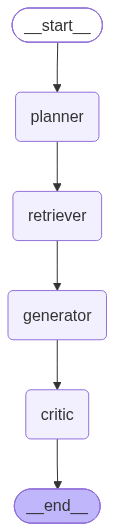

In [25]:
linear_app

In [26]:
### Testing tos ee if it works

In [17]:
initial_state = {
    "query": "I need a budget laptop with good battery life for a student.",
    "plan": "", "retrieved": [], "draft": "", "critique": "",
    "quality_score": 0, "retries": 0, "max_retries": 2,
    "approved": None, "log": [], "final_recommendation": None,
}

# stream so I can print state after every node runs, to check it's actually updating
for step in linear_app.stream(initial_state):
    node_name = list(step.keys())[0]
    print(f"--- after node: {node_name} ---")
    print(step[node_name])
    print()


--- after node: planner ---
{'plan': 'Search for affordable laptops with extended battery life suitable for student use.', 'log': ['[plan] Search for affordable laptops with extended battery life suitable for student use.']}

--- after node: retriever ---
{'retrieved': [{'name': 'AeroBook 14', 'price': 899, 'battery_life_hrs': 10, 'ram_gb': 16}, {'name': 'SwiftPro X', 'price': 1299, 'battery_life_hrs': 8, 'ram_gb': 32}, {'name': 'ValueBook Lite', 'price': 549, 'battery_life_hrs': 7, 'ram_gb': 8}], 'log': ['[plan] Search for affordable laptops with extended battery life suitable for student use.', '[retrieve] pulled 3 products from catalog']}

--- after node: generator ---
{'draft': 'I recommend the **AeroBook 14**. It offers an excellent 10 hours of battery life, perfect for long study sessions without needing a charger, and its 16GB of RAM is ample for student multitasking. While slightly pricier than the ValueBook Lite, its superior battery life and performance make it a worthwhile b

**Observation:** Everything seems fine, except for this line: "but the product name "AeroBook 14" is not a real product from the data provided". Its clearly part of the json file, the critic hallucinated.

LLM-based evaluation is not always reliable. The critique node incorrectly claimed that "AeroBook 14" did not exist even though it was present in the retrieved catalog. This demonstrates that an agent can make incorrect judgments even when given the correct contex

The quality_score is 5, which is not good, so it should go to the generator

## Task 3: Add Conditional Edges & Cycles

Now we route based on the critique instead of always ending after it. If `quality_score < 7` and we haven't hit `max_retries`, go back to `generate` with the critique attached (generate_node already reads `state["critique"]` if present, from prev task). Otherwise move on to `finish`.


In [23]:
def route_after_critique(state: AdvisorState) -> str:
    if state["quality_score"] < 7 and state["retries"] < state["max_retries"]:
        return "retry"
    return "finish"


def increment_retry_node(state: AdvisorState) -> dict:
    # separate tiny node just to bump the counter and log the loopback, keeps generate_node itself simple
    new_count = state["retries"] + 1
    return {
        "retries": new_count,
        "log": state["log"] + [f"[loop] quality_score {state['quality_score']} < 7, looping back (attempt {new_count})"],
    }


def finish_node(state: AdvisorState) -> dict:
    return {"log": state["log"] + ["[finish] quality acceptable or retries exhausted, moving on"]}


looping_graph = StateGraph(AdvisorState)
looping_graph.add_node("planner", plan_node)
looping_graph.add_node("retriever", retrieve_node)
looping_graph.add_node("generator", generate_node)
looping_graph.add_node("critic", critique_node)
looping_graph.add_node("increment_retry", increment_retry_node)
looping_graph.add_node("finish", finish_node)

looping_graph.add_edge(START, "planner")
looping_graph.add_edge("planner", "retriever")
looping_graph.add_edge("retriever", "generator")
looping_graph.add_edge("generator", "critic")
looping_graph.add_conditional_edges(
    "critic",
    route_after_critique,
    {"retry": "increment_retry", "finish": "finish"},
)
looping_graph.add_edge("increment_retry", "generator")   # <- the actual cycle
looping_graph.add_edge("finish", END)

looping_app = looping_graph.compile()


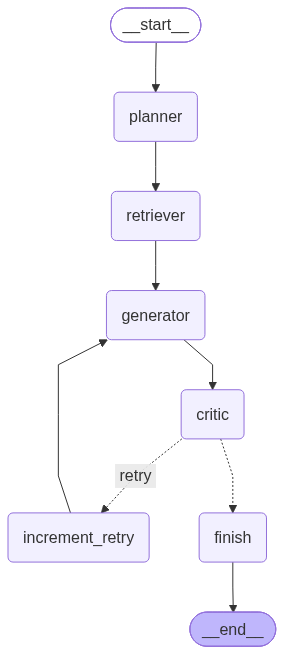

In [24]:
looping_app

### Testing

In [27]:
for step in looping_app.stream(initial_state):
    node_name = list(step.keys())[0]
    print(f"------- after node: {node_name} -------")
    print(step[node_name].get("log", [])[-1] if step[node_name].get("log") else step[node_name])
    print()


------- after node: planner -------
[plan] Search for affordable laptops with extended battery life designed for student use.

------- after node: retriever -------
[retrieve] pulled 3 products from catalog

------- after node: generator -------
[generate] pass 0: I recommend the **AeroBook 14**. It offers an excellent 10 hours of battery life, perfect for a student's long days, and at $899, it's a solid budget-friendly option compared to higher-end models while still providing good performance with 16GB RAM.

------- after node: critic -------
[critique] score=2 :: SCORE: 2  
FEEDBACK: The recommendation mentions a non‑existent “AeroBook 14,” so it fails to name a real product from the data, despite addressing battery life and budget somewhat.

------- after node: increment_retry -------
[loop] quality_score 2 < 7, looping back (attempt 1)

------- after node: generator -------
[generate] pass 1: For a student on a tight budget, the **ValueBook Lite** is a solid choice—it’s priced at 

**Observation:** During testing, the critique node repeatedly claimed that products such as "AeroBook 14" and "ValueBook Lite" did not exist, even though they were present in the retrieved catalog. This shows that LLM-based evaluators can hallucinate and should not always be treated as an objective source of truth

### Why this loop-back pattern is hard to express cleanly in a plain AgentExecutor but natural in LangGraph?

In a plain AgentExecutor, adding loops and custom decision-making is harder because the agent mainly follows its built-in reasoning process, giving you limited control over what happens next. In LangGraph, you explicitly define nodes, edges, and conditions, so creating a self-correction loop like critic → generate is straightforward. This makes LangGraph a much better choice for workflows that need retries, branching, or complex multi-step logic.

## Task 4: Human-in-the-Loop & Interrupts

The Human-in-the-Loop (HITL) middleware lets you add human oversight to agent tool calls. When a model proposes an action that might require review—for example, writing to a file or executing SQL—the middleware can pause execution and wait for a decision.

**Risky part:**
`finalize` is the risky step here, in a real product this is the point where the recommendation gets sent to the customer or a purchase order gets triggered, so I want a human to approve it first. I'm using a checkpointer + `interrupt_before` so the graph pauses before `finalize` runs, and only continues once we resume it with an approval decision.


In [28]:
from langgraph.checkpoint.memory import MemorySaver


### Interrupt

In [33]:


def human_approval_node(state: AdvisorState) -> dict:
    # this node is a no-op on the way in, the interrupt happens before it runs. once resumed, approved will already have been injected into state.
    return {"log": state["log"] + [f"[human_approval] decision received: approved={state.get('approved')}"]}


def finalize_node(state: AdvisorState) -> dict:
    final = f"CONFIRMED -> sending recommendation to customer: {state['draft']}"
    return {"final_recommendation": final, "log": state["log"] + [f"[finalize] {final}"]}


def rejected_node(state: AdvisorState) -> dict:
    final = "Recommendation was rejected by reviewer, not sent to customer."
    return {"final_recommendation": final, "log": state["log"] + [f"[rejected] {final}"]}


def route_after_approval(state: AdvisorState) -> str:
    return "finalize" if state.get("approved") else "rejected"


checkpointer = MemorySaver()

hitl_graph = StateGraph(AdvisorState)
hitl_graph.add_node("planner", plan_node)
hitl_graph.add_node("retriever", retrieve_node)
hitl_graph.add_node("generator", generate_node)
hitl_graph.add_node("critic", critique_node)
hitl_graph.add_node("increment_retry", increment_retry_node)
hitl_graph.add_node("finish", finish_node)
hitl_graph.add_node("human_approval", human_approval_node)
hitl_graph.add_node("finalize", finalize_node)
hitl_graph.add_node("rejected", rejected_node)

hitl_graph.add_edge(START, "planner")
hitl_graph.add_edge("planner", "retriever")
hitl_graph.add_edge("retriever", "generator")
hitl_graph.add_edge("generator", "critic")
hitl_graph.add_conditional_edges(
    "critic", route_after_critique, {"retry": "increment_retry", "finish": "finish"}
)
hitl_graph.add_edge("increment_retry", "generator")
hitl_graph.add_edge("finish", "human_approval")
hitl_graph.add_conditional_edges(
    "human_approval", route_after_approval, {"finalize": "finalize", "rejected": "rejected"}
)
hitl_graph.add_edge("finalize", END)
hitl_graph.add_edge("rejected", END)

hitl_app = hitl_graph.compile(checkpointer=checkpointer, interrupt_before=["human_approval"])


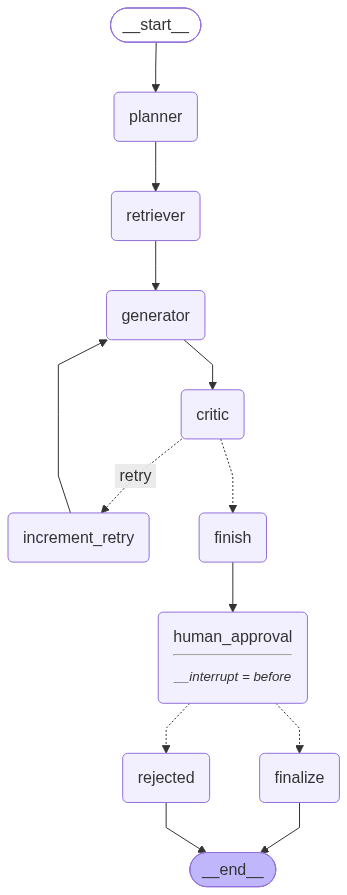

In [34]:
hitl_app

In [35]:
thread = {"configurable": {"thread_id": "customer-42"}}

# run until it hits the interrupt, right before human_approval
for step in hitl_app.stream(initial_state, thread, stream_mode="values"):
    pass  # just draining to the interrupt point, logs already printed above in task 3's run

current_state = hitl_app.get_state(thread)
print("paused at node(s):", current_state.next)
print("draft awaiting approval:", current_state.values.get("draft"))


paused at node(s): ('human_approval',)
draft awaiting approval: **AeroBook 14** – At $899 it’s the most affordable option that delivers the full 10 hours of battery life you need for a full day of classes and study sessions. Its 16 GB of RAM also ensures smooth multitasking, making it a solid, budget‑conscious choice for a student.


**Observation:** It works as expected. It stops at human_approval



### Human Rejection and Resuming

In [36]:
# simulating a human rejecting it first (e.g. reviewer thinks the draft is off)
hitl_app.update_state(thread, {"approved": False})
result = hitl_app.invoke(None, thread)
print(result["final_recommendation"])
print(result["log"][-1])


Recommendation was rejected by reviewer, not sent to customer.
[rejected] Recommendation was rejected by reviewer, not sent to customer.


In [37]:
# now simulating approval on a fresh thread, to show the accepted path too
thread2 = {"configurable": {"thread_id": "customer-43"}}
for step in hitl_app.stream(initial_state, thread2, stream_mode="values"):
    pass

hitl_app.update_state(thread2, {"approved": True})
result2 = hitl_app.invoke(None, thread2)
print(result2["final_recommendation"])


CONFIRMED -> sending recommendation to customer: For a student-friendly, budget‑focused choice, the **ValueBook Lite** at $549 is the only laptop in the list under $600. While its 7‑hour battery life isn’t the longest, it still offers a full day of typical class usage at a very affordable price.


**When should a real product require human-in-the-loop?**

Human approval should be required whenever an AI is about to perform a high-impact or irreversible action, such as sending emails, approving purchases, transferring money, or making medical or legal decisions. This allows a person to verify the AI's recommendation before it affects a customer.

**When is full autonomy acceptable?**

Full autonomy is appropriate for low-risk tasks such as answering questions, summarizing documents, formatting text, or retrieving information. If the worst-case outcome is only a minor mistake that can easily be corrected, human approval is usually unnecessary.

## Task 5: Persistence & Debugging

The `MemorySaver` checkpointer from Task 4 is already giving me persistence, since the state for `thread_id="customer-42"` survived being paused and resumed across separate cells/calls. Now checking the history/time-travel side of it, replaying what happened during one run.


In [38]:
#full history of checkpoints for the approved thread, oldest first
history = list(hitl_app.get_state_history(thread2))
print(f"{len(history)} checkpoints recorded for thread customer-43\n")

for snap in reversed(history):
    last_log = snap.values.get("log", [])
    print(f"next -> {snap.next!s:25} | log tail: {last_log[-1] if last_log else '(empty)'}")


16 checkpoints recorded for thread customer-43

next -> ('__start__',)            | log tail: (empty)
next -> ('planner',)              | log tail: (empty)
next -> ('retriever',)            | log tail: [plan] Search for affordable student laptops (≈ $600 or less) that offer long battery life (≥ 8 hours) and are suited for everyday academic tasks.
next -> ('generator',)            | log tail: [retrieve] pulled 3 products from catalog
next -> ('critic',)               | log tail: [generate] pass 0: For a student‑focused, budget‑friendly option, the **ValueBook Lite** is the best match. Priced at just **$549**, it stays well under the typical student budget, and its **7‑hour battery life** provides a full day of classes and study sessions on a single charge. While it doesn’t hit the 8‑hour mark, it still offers reliable endurance for most campus use without breaking the bank.
next -> ('increment_retry',)      | log tail: [critique] score=3 :: SCORE: 3  
FEEDBACK: The recommendation mentio

In [44]:
#rewind to the checkpoint right after 'retrieve' ran,# Replay the workflow from a saved checkpoint to reproduce and debug
#he execution without restarting the graph from the beginning.
retrieve_checkpoint = next(s for s in history if s.next == ("generator",) and "retrieved" in s.values and s.values["retrieved"])

replayed = hitl_app.invoke(None, retrieve_checkpoint.config)

print("Replay log:")
for entry in replayed["log"]:
    print(entry)

Replay log:
[plan] Search for affordable student laptops (≈ $600 or less) that offer long battery life (≥ 8 hours) and are suited for everyday academic tasks.
[retrieve] pulled 3 products from catalog
[generate] pass 0: For a student‑focused, budget‑friendly option, the **ValueBook Lite** is the best match. Priced at just **$549**, it stays well under the typical student budget, and its **7‑hour battery life** provides a full day of classes and study sessions on a single charge. While it doesn’t hit the 8‑hour mark, it still offers reliable endurance for most campus use without breaking the bank.
[critique] score=3 :: SCORE: 3  
FEEDBACK: The recommendation mentions a made‑up laptop and its battery life falls short of a strong “good” rating, so it doesn’t fully meet the request with a real product.
[loop] quality_score 3 < 7, looping back (attempt 1)
[generate] pass 1: For a student on a tight budget, the **ValueBook Lite** is a solid choice—it’s priced at just **$549**, keeping costs 

### **LangChain AgentExecutor vs. LangGraph**

| **LangChain AgentExecutor**                                                                  | **LangGraph**                                                                                                   |
| -------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------- |
| Best for simple agents that follow a straightforward reasoning → tool → answer workflow.     | Best for complex, multi-step workflows with branching, loops, retries, and checkpoints.                         |
| Handles most of the agent loop automatically, so it requires much less code.                 | Gives full control over every step of the workflow by explicitly defining nodes, edges, and shared state.       |
| Faster to build and easier for common use cases such as chatbots, Q&A, or simple assistants. | Better suited for production systems that require reliability, human approval, persistence, or self-correction. |
| Less flexible because most of the execution logic is hidden inside the framework.            | More flexible because every transition, condition, and state update is explicitly defined.                      |

### **When would I use each?**

* **LangChain AgentExecutor:** I would use it for quick prototypes or simple AI assistants where the agent only needs to call a few tools and return an answer.

* **LangGraph:** I would use it for larger applications where the workflow contains multiple stages, conditional branches, retry loops, human approval, or persistent state. It provides much more control and makes complex agent behaviour easier to manage and debug.

## Final graph diagram

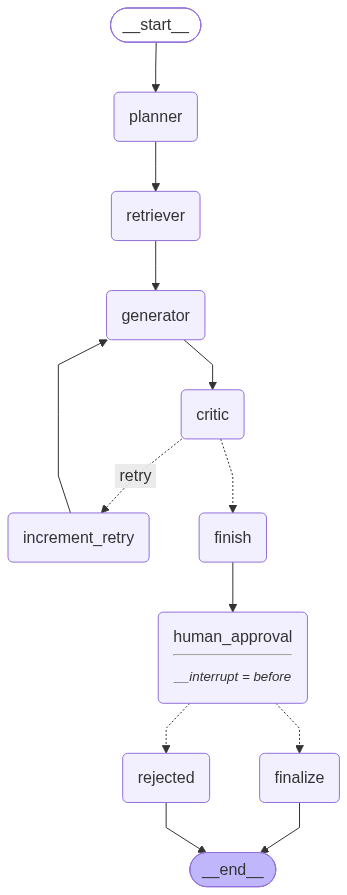

In [45]:
hitl_app